In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random
import csv

from scipy.integrate import odeint
from matplotlib.ticker import MultipleLocator

In [3]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

### Parameters and initial conditions

In [46]:
# Parameters
N = 100  # Number of houses 

''' Parameters just for scaling plots
kappa = 3.5
e = 1.1  #omega in the paper
v_w = 0.8
sigma = 0.1
gamma = 0.25
beta = 0
'''

kappa = 3.5
e = 1.1  #omega in the paper
v_w = 0.8
sigma = 0.01
gamma = 0.03
beta = 0

dt = 0.021 # Time step size in years (1 week)
T = round(30/dt)  # Number of time steps (in years) 

# State encoding
R = 'R'  
W = 'W'
V = 'V' 
Out = 'Out'

# Initial conditions
R0 = 70
W0 = 20
V0 = 10

In [4]:
# Define networks

# k1_avg = np.round(N ** (1/7)).astype(int) # In-city network
# k2_avg = np.round(N ** (1/6)).astype(int)

k1_avg = 4 # In-city network
k2_avg = 14
p1 = k1_avg/N  # Link probability for the Erdos-Rényi network (average degree ⟨k⟩)
p2 = k2_avg/N

m1 = 2
m2 = 7

k1 = k1_avg
pw1 = 0.01
k2 = k2_avg
pw2 = 0.01


# Erdos-Rényi network inside the city 
G1_Random = nx.erdos_renyi_graph(N, p1) 
G2_Random = nx.erdos_renyi_graph(N, p2)
#G2 = nx.complete_graph(N) 

# Scale-free network
G1_ScaleFree = nx.barabasi_albert_graph(N, m1) #static Barabási–Albert graph
G2_ScaleFree = nx.barabasi_albert_graph(N, m2) 

# Small world
G1_SmallWorld = nx.watts_strogatz_graph(N, k1, pw1)
G2_SmallWorld = nx.watts_strogatz_graph(N, k2, pw2)

NameError: name 'N' is not defined

In [33]:
# Plot the network
'''
pos = nx.spring_layout(G2_SmallWorld, seed=42)  

plt.figure(figsize=(6,6))
nx.draw_networkx_edges(G2_SmallWorld, pos, alpha=0.3, width=0.5)
nx.draw_networkx_nodes(G2_SmallWorld, pos,
                       node_size=30,
                       node_color='skyblue',
                       edgecolors='k',
                       linewidths=0.2)
plt.axis('off')
plt.title("Static network")
plt.show()


# Degree histogram
deg = [d for n, d in G2_SmallWorld.degree()]
plt.figure()
plt.hist(deg, bins=30, edgecolor='k')
plt.xlabel("Degree")
plt.ylabel("Count")
plt.title("Degree distribution")
plt.show()

# Clustering coefficient
cc = nx.clustering(G2_SmallWorld)
plt.figure()
plt.hist(list(cc.values()), bins=20, edgecolor='k')
plt.xlabel("Local clustering")
plt.ylabel("Count")
plt.title("Node clustering coefficients")
plt.show()
'''

'\npos = nx.spring_layout(G2_SmallWorld, seed=42)  \n\nplt.figure(figsize=(6,6))\nnx.draw_networkx_edges(G2_SmallWorld, pos, alpha=0.3, width=0.5)\nnx.draw_networkx_nodes(G2_SmallWorld, pos,\n                       node_size=30,\n                       node_color=\'skyblue\',\n                       edgecolors=\'k\',\n                       linewidths=0.2)\nplt.axis(\'off\')\nplt.title("Static network")\nplt.show()\n\n\n# Degree histogram\ndeg = [d for n, d in G2_SmallWorld.degree()]\nplt.figure()\nplt.hist(deg, bins=30, edgecolor=\'k\')\nplt.xlabel("Degree")\nplt.ylabel("Count")\nplt.title("Degree distribution")\nplt.show()\n\n# Clustering coefficient\ncc = nx.clustering(G2_SmallWorld)\nplt.figure()\nplt.hist(list(cc.values()), bins=20, edgecolor=\'k\')\nplt.xlabel("Local clustering")\nplt.ylabel("Count")\nplt.title("Node clustering coefficients")\nplt.show()\n'

## Mean-field approx.

In [35]:
# Parameters
N = 100  # Number of houses 

kappa = 3.5
e = 3  #omega in the paper
v_w = 0.8
sigma = 0.01
gamma = 0.03
beta = 0

#dt = 0.021 # Time step size in years (1 week)
dt = 0.021 # Time step size in years (1 week)
T = round(100/dt)  # Number of time steps (in years) Here is 15 years

# State encoding
R = 'R'  
W = 'W'
V = 'V' 
Out = 'Out'

# Initial conditions
R0 = 70
W0 = 20
V0 = 10

In [36]:
# Solve the ODEs
def model(y, t, kappa, e, v_w, beta, sigma, gamma, k1, k2, H):
    R, W, V = y
    
    dR_dt = kappa*W - e*R - (k1*sigma/H)*(R*V) + (k2*gamma/H)*(V*R) + beta*V
    dW_dt = -kappa*W + e*R - v_w*W + (k1*sigma/H)*(R*V)
    dV_dt = v_w*W - (k2*gamma/H)*(R*V) - beta*V 
    
    return [dR_dt, dW_dt, dV_dt]

t = np.linspace(0, T * dt, T+1) # Adjust if needed
y0 = [R0, W0, V0]
solution = odeint(model, y0, t, args=(kappa, e, v_w, beta, sigma, gamma, k1_avg, k2_avg, N))
R_sol, W_sol, V_sol = solution.T

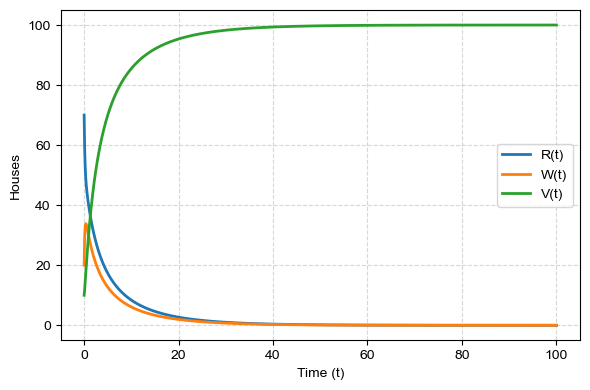

In [37]:
plt.figure(figsize=(6, 4))
plt.plot(t, R_sol, label='R(t)', lw = 2)
plt.plot(t, W_sol, label='W(t)', lw = 2)
plt.plot(t, V_sol, label='V(t)', lw = 2)

plt.xlabel('Time (t)')
plt.ylabel('Houses')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Simulations

In [77]:
# Determine the next state of an individual based on their current state and interactions.
def transition(state, neighbors1, neighbors2, left):
    new_state = state  # Default to staying in the same state

    if state == R:
        vacant_neighbors = sum(1 for n in neighbors1 if n == V)
        p_exh = 1 - (1 - sigma * dt) ** (vacant_neighbors) 
        if np.random.rand() < p_exh or np.random.rand() < e * dt:
            new_state = W

    elif state == W:
        if np.random.rand() < kappa * dt:
            new_state = R
        elif np.random.rand() < v_w * dt:
            new_state = V  # Leave the city
            left += 1  # Increment left counter
            
    elif state == V:
        res_neighbors = sum(1 for n in neighbors2 if n == R)
        p_in = 1 - (1 - gamma * dt) ** res_neighbors
        if np.random.rand() < beta * dt or np.random.rand() < p_in:
        #if outsiders > 0 and np.random.rand() < p_in:
            new_state = R

    return new_state, left

# -----------------------------------------------------------------------------------------------
# Simulations with networks (Random, Scale-free, Small-world)
def run_simulation(initial_R, initial_W, initial_V, G1, G2):

    states = np.array([R]*initial_R + [W]*initial_W + [V]*initial_V) #Set initial state
    
    #np.random.shuffle(states) # Shuffle the initial state randomly

    # Track the states over time
    history = np.zeros((T+1, 3))  # For storing the count of Rooted, Wishful or Vacant at each time step
    history[0, 0] = np.sum(states == R)  
    history[0, 1] = np.sum(states == W)  
    history[0, 2] = np.sum(states == V) 

    left = 0
    #outsiders = float('inf')

    for t in range(1, T+1):
        next_states = np.copy(states) # Create a copy of the current state to store the next state

        # Iterate over each individual and update their state
        for i in range(N):
            neighbors1 = [states[n] for n in G1.neighbors(i)]
            neighbors2 = [states[n] for n in G2.neighbors(i)]

            # Update state and track the number of people who left
            new_state, left = transition(states[i], neighbors1, neighbors2, left)
            next_states[i] = new_state

        # Store the state counts
        history[t, 0] = np.sum(next_states == R)  
        history[t, 1] = np.sum(next_states == W) 
        history[t, 2] = np.sum(next_states == V) 
        
        # Update states for the next time step
        states = next_states

    return history, left

### Run Simulations

In [78]:
num_simulations = 200

In [79]:
### Random
all_simulations_Random = np.zeros((num_simulations, T+1, 3))
all_left_Random = np.zeros(num_simulations)

for sim in range(num_simulations):
    history_Random, left_Random = run_simulation(R0, W0, V0, G1_Random, G2_Random)
    all_simulations_Random[sim] = history_Random
    all_left_Random[sim] = left_Random

# Mean and sd at each time step
mean_states_Random = np.mean(all_simulations_Random, axis = 0)
std_states_Random = np.std(all_simulations_Random, axis = 0)

## mean_left_Random = np.mean(all_left_Random)
## std_left_Random = np.std(all_left_Random)

In [80]:
### Scale-free
all_simulations_ScaleFree = np.zeros((num_simulations, T+1, 3))
all_left_ScaleFree = np.zeros(num_simulations)

for sim in range(num_simulations):
    history_ScaleFree, left_ScaleFree = run_simulation(R0, W0, V0, G1_ScaleFree, G2_ScaleFree)
    all_simulations_ScaleFree[sim] = history_ScaleFree
    all_left_ScaleFree[sim] = left_ScaleFree

# Mean and sd
mean_states_ScaleFree = np.mean(all_simulations_ScaleFree, axis = 0)
std_states_ScaleFree = np.std(all_simulations_ScaleFree, axis = 0)

In [81]:
### Small-world
all_simulations_SmallWorld = np.zeros((num_simulations, T+1, 3))
all_left_SmallWorld = np.zeros(num_simulations)

for sim in range(num_simulations):
    history_SmallWorld, left_SmallWorld = run_simulation(R0, W0, V0, G1_SmallWorld, G2_SmallWorld)
    all_simulations_SmallWorld[sim] = history_SmallWorld
    all_left_SmallWorld[sim] = left_SmallWorld

# Mean and sd
mean_states_SmallWorld = np.mean(all_simulations_SmallWorld, axis = 0)
std_states_SmallWorld = np.std(all_simulations_SmallWorld, axis = 0)

In [82]:
simData = [(mean_states_Random, std_states_Random, "Random"),
    (mean_states_ScaleFree, std_states_ScaleFree, "Scale-free"),
    (mean_states_SmallWorld,std_states_SmallWorld, "Small-world")]

# Save
with open('.../Simulations/simData_10_28_N1000.csv', 'w', newline = '') as f:
    writer = csv.writer(f)
    T_plus_1, n_compartments = simData[0][0].shape 
    header = ['label'] + \
             [f'mean_{i}' for i in range(T_plus_1 * n_compartments)] + \
             [f'std_{i}' for i in range(T_plus_1 * n_compartments)]
    writer.writerow(header)
    
    for mean_arr, std_arr, label in simData:
        mean_flat = mean_arr.flatten()
        std_flat = std_arr.flatten()
        row = [label] + mean_flat.tolist() + std_flat.tolist()
        writer.writerow(row)

In [50]:
T_plus_1 = T + 1
n_compartments = 3

# Load simulations data
with open('.../Simulations/simData_10_28_N1000.csv', newline='') as f:
    reader = csv.reader(f)
    header = next(reader)  # skip header

    loaded_data = []
    for row in reader:
        label = row[0]
        numbers = np.array(row[1:], dtype=float)
        
        half = len(numbers)//2
        mean_flat = numbers[:half]
        std_flat = numbers[half:]
        
        # reshape back to original shape
        mean_arr = mean_flat.reshape((T_plus_1, n_compartments))
        std_arr = std_flat.reshape((T_plus_1, n_compartments))
        
        loaded_data.append((mean_arr, std_arr, label))

simData= loaded_data

### Plots

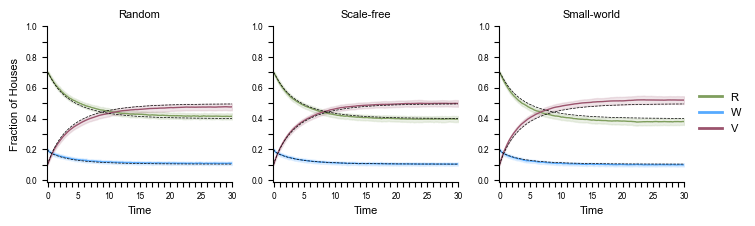

In [51]:
colors = ['#7f9e5d', '#56aaff', '#9b536d']
labels = ['R', 'W', 'V']

single_mm = 60
height_in = 60 / 25.4

width_in  = (3 * single_mm) / 25.4

fig, axes = plt.subplots(1, 3, figsize = (width_in, height_in),
                         sharey = False,  # same y‐axis scale
                         sharex = True)  # same x‐axis scale

for ax, (mean_s, std_s, title) in zip(axes, simData):
    # plot each compartment
    for i in range(3):
        t_grid = np.arange(T + 1) * dt
        ax.plot(t_grid, mean_s[:, i] / N,
                color=colors[i], lw = 1, alpha = 1)
        ax.fill_between(t_grid,
                        (mean_s[:, i] - std_s[:, i]) / N,
                        (mean_s[:, i] + std_s[:, i]) / N,
                        color = colors[i], alpha = 0.15)

    # overlay ODE solution
    for sol in [R_sol, W_sol, V_sol]:
        ax.plot(t, sol/N, '--', color = 'black', lw = 0.5)

    ax.set_title(title, fontsize = 12)
    ax.set_xlabel('Time', fontsize = 8)
    ax.set_xlim(-0.1, 30)
    ax.set_xticks(np.arange(0, t_grid[-1], 1))
    ax.set_xticklabels([str(int(i)) if i % 5 == 0 else "" for i in np.arange(0, t_grid[-1], 1)], fontsize=6)

    ax.set_title(title, fontsize=8)
    
    if ax is axes[0]:  
        ax.set_ylabel('Fraction of Houses', fontsize=8)
    
    ax.set_ylim(-0.01, 1)
    ax.set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    ax.set_yticklabels(["0.0","","0.2","","0.4","","0.6","","0.8","","1.0"], fontsize=6)

    ax.tick_params(axis='both', colors = "black", labelsize = 6)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color('black')

handles = [plt.Line2D([0], [0], color = colors[i], lw = 2) for i in range(len(labels))]
fig.legend(handles, labels,
           loc ='center left',
           bbox_to_anchor = (0.98, 0.5),
           fontsize = 8,
           frameon = False)

fig.tight_layout()
plt.show()